# ✅ Improved Age & Gender Multi-Task CNN

## Key Improvements Over Original:
| Issue | Original | Improved |
|-------|----------|----------|
| Backbone | ResNet50 fully frozen | EfficientNetB3 + staged fine-tuning |
| Pooling | Flatten (unstable) | GlobalAveragePooling2D |
| Age normalization | Raw 0–116 | Normalized to 0–1 |
| Loss weights | 1:99 (catastrophic) | Balanced 1:1 with proper scaling |
| Age loss | MAE only | MSE (better gradients) + MAE metric |
| Callbacks | None | EarlyStopping + ReduceLROnPlateau + ModelCheckpoint |
| Branches | Dense only | Dense + BatchNormalization |
| History | Not saved (crashes plot) | Properly saved |
| Fine-tuning | None | Staged: freeze → train head → unfreeze top layers |

In [1]:
# ── Setup Kaggle ──────────────────────────────────────────────────────────────
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 92% 305M/331M [00:00<00:00, 889MB/s] 
100% 331M/331M [00:00<00:00, 815MB/s]


In [3]:
import zipfile
with zipfile.ZipFile('/content/utkface-new.zip', 'r') as z:
    z.extractall('/content')

In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow: 2.19.0
GPUs available: 1


In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
FOLDER_PATH = '/content/utkface_aligned_cropped/UTKFace'
IMG_SIZE    = 128       # EfficientNetB3 native input; smaller = faster training
BATCH_SIZE  = 32
MAX_AGE     = 100.0     # Normalize age to [0, 1] → CRITICAL for stable training
SEED        = 42

# Stage 1: Train head only
STAGE1_EPOCHS = 15
STAGE1_LR     = 1e-3

# Stage 2: Fine-tune top layers of backbone
STAGE2_EPOCHS = 25
STAGE2_LR     = 1e-4    # Much lower LR for fine-tuning

In [6]:
# ── Build DataFrame ───────────────────────────────────────────────────────────
ages, genders, img_paths = [], [], []

for fname in os.listdir(FOLDER_PATH):
    parts = fname.split('_')
    try:
        age    = int(parts[0])
        gender = int(parts[1])
        # FIX: Filter out invalid/corrupt entries (age=0 often noisy, >116 invalid)
        if 1 <= age <= 116 and gender in [0, 1]:
            ages.append(age)
            genders.append(float(gender))
            img_paths.append(fname)
    except (ValueError, IndexError):
        pass    # Skip malformed filenames

df = pd.DataFrame({'img': img_paths, 'age': ages, 'gender': genders})

# KEY FIX: Normalize age to [0, 1] — raw ages (0–116) destabilize gradient flow
df['age_norm'] = (df['age'] / MAX_AGE).clip(0, 1)

print(f'Dataset size: {len(df)}')
print(f'Age range: {df["age"].min()}–{df["age"].max()}')
print(f'Gender balance: {df["gender"].value_counts().to_dict()}')

Dataset size: 23708
Age range: 1–116
Gender balance: {0.0: 12391, 1.0: 11317}


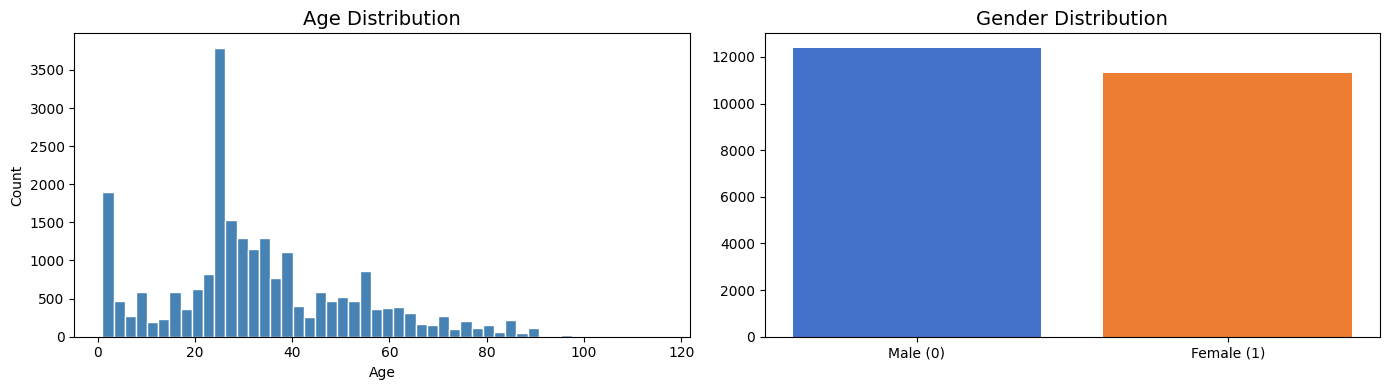

In [7]:
# ── Visualize Dataset Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['age'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].bar(['Male (0)', 'Female (1)'], df['gender'].value_counts().sort_index(),
            color=['#4472CA', '#ED7D31'])
axes[1].set_title('Gender Distribution', fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
# ── Train / Validation Split ──────────────────────────────────────────────────
# Shuffle once, then split deterministically
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split_idx = int(len(df) * 0.85)
train_df  = df.iloc[:split_idx].reset_index(drop=True)
val_df    = df.iloc[split_idx:].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)}')

Train: 20151 | Val: 3557


In [9]:
# ── Data Generators ───────────────────────────────────────────────────────────
# NOTE: EfficientNet has its own built-in preprocessing, so we do NOT rescale here.
# We apply augmentation only on training data.
train_datagen = ImageDataGenerator(
    # EfficientNet expects [0,255] — no rescale needed
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],   # New: simulate lighting variation
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # No augmentation on validation

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=FOLDER_PATH,
    x_col='img',
    y_col=['age_norm', 'gender'],   # Use normalized age
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=FOLDER_PATH,
    x_col='img',
    y_col=['age_norm', 'gender'],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    seed=SEED,
    shuffle=False
)

Found 20151 validated image filenames.
Found 3557 validated image filenames.


In [10]:
# ── Multi-task Generator ───────────────────────────────────────────────────────
def multitask_generator(generator):
    """Split the (age_norm, gender) columns into separate named outputs."""
    while True:
        X, y = next(generator)
        yield X, {'age': y[:, 0], 'gender': y[:, 1]}

train_gen = multitask_generator(train_generator)
val_gen   = multitask_generator(val_generator)

In [11]:
# ── Build Model ───────────────────────────────────────────────────────────────
from tensorflow.keras.layers import Rescaling

def build_model(backbone_trainable=False):
    # Manual input + rescaling (replaces include_preprocessing=True)
    inputs   = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x_scaled = Rescaling(1.0 / 255.0)(inputs)  # [0,255] → [0,1]

    # Backbone
    backbone = EfficientNetB3(
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        weights='imagenet'
    )
    backbone.trainable = backbone_trainable

    x      = backbone(x_scaled)
    shared = layers.GlobalAveragePooling2D()(x)
    shared = layers.Dropout(0.3)(shared)

    # ─── Age Branch ───────────────────────────────────────────────────────────
    age_x = layers.Dense(256, activation='relu')(shared)
    age_x = layers.BatchNormalization()(age_x)
    age_x = layers.Dropout(0.3)(age_x)
    age_x = layers.Dense(128, activation='relu')(age_x)
    age_x = layers.BatchNormalization()(age_x)
    age_x = layers.Dropout(0.2)(age_x)
    age_out = layers.Dense(1, activation='sigmoid', name='age')(age_x)

    # ─── Gender Branch ────────────────────────────────────────────────────────
    gen_x = layers.Dense(256, activation='relu')(shared)
    gen_x = layers.BatchNormalization()(gen_x)
    gen_x = layers.Dropout(0.3)(gen_x)
    gen_x = layers.Dense(128, activation='relu')(gen_x)
    gen_x = layers.BatchNormalization()(gen_x)
    gen_x = layers.Dropout(0.2)(gen_x)
    gen_out = layers.Dense(1, activation='sigmoid', name='gender')(gen_x)

    # ✅ Use `inputs` (not backbone.input) as the model entry point
    model = Model(inputs=inputs, outputs=[age_out, gen_out])
    return model, backbone

model, backbone = build_model(backbone_trainable=False)
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 4, 4,      │ 10,783,535 │ rescaling[0][0]   │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1536)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    393,472 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    393,472 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,639,601 (44.40 MB)

 Trainable params: 854,530 (3.26 MB)

 Non-trainable params: 10,785,071 (41.14 MB)

In [12]:
# ── Compile Helper ────────────────────────────────────────────────────────────
def compile_model(model, lr):
    """
    FIX 6: Use MSE for age (better gradients than MAE for regression)
    FIX 7: Balanced loss weights — age:1, gender:1 since both are [0,1] scale now
    """
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={
            'age':    'mse',                 # MSE for regression on normalized [0,1] target
            'gender': 'binary_crossentropy'  # BCE for binary classification
        },
        metrics={
            'age':    ['mae'],               # Report MAE in years (multiply by MAX_AGE)
            'gender': ['accuracy']
        },
        loss_weights={'age': 1.0, 'gender': 1.0}  # Equal — both tasks are equally important
    )
    return model

compile_model(model, lr=STAGE1_LR)

<Functional name=functional, built=True>

In [13]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
# FIX 8: Add proper callbacks — original had NONE of these
callbacks_stage1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_stage1.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

callbacks_stage2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_stage2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [14]:
# ── Stage 1: Train Head Only (Backbone Frozen) ───────────────────────────────
print('=' * 60)
print('STAGE 1: Training classification head (backbone frozen)')
print('=' * 60)

steps_per_epoch_train = len(train_df) // BATCH_SIZE
steps_per_epoch_val   = len(val_df)   // BATCH_SIZE

# FIX 9: Assign model.fit() to history — original forgot this, causing plot crash
history1 = model.fit(
    train_gen,
    epochs=STAGE1_EPOCHS,
    steps_per_epoch=steps_per_epoch_train,
    validation_data=val_gen,
    validation_steps=steps_per_epoch_val,
    callbacks=callbacks_stage1,
    verbose=1
)

print('\nStage 1 complete!')

STAGE 1: Training classification head (backbone frozen)
Epoch 1/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - age_loss: 0.0799 - age_mae: 0.2210 - gender_accuracy: 0.5097 - gender_loss: 0.8110 - loss: 0.8909
Epoch 1: val_loss improved from inf to 0.73662, saving model to best_stage1.keras
629/629 ━━━━━━━━━━━━━━━━━━━━ 170s 192ms/step - age_loss: 0.0799 - age_mae: 0.2209 - gender_accuracy: 0.5097 - gender_loss: 0.8109 - loss: 0.8908 - val_age_loss: 0.0405 - val_age_mae: 0.1545 - val_gender_accuracy: 0.4856 - val_gender_loss: 0.6961 - val_loss: 0.7366 - learning_rate: 0.0010
Epoch 2/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - age_loss: 0.0429 - age_mae: 0.1619 - gender_accuracy: 0.5037 - gender_loss: 0.7151 - loss: 0.7579
Epoch 2: val_loss improved from 0.73662 to 0.73266, saving model to best_stage1.keras
629/629 ━━━━━━━━━━━━━━━━━━━━ 138s 176ms/step - age_loss: 0.0429 - age_mae: 0.1619 - gender_accuracy: 0.5037 - gender_loss: 0.7151 - loss: 0.7579 - val_age_loss: 0.0404 - val_age_m

In [15]:
# ── Stage 2: Fine-tune Top Layers of Backbone ─────────────────────────────────
# FIX 10: Staged fine-tuning — unfreeze only the top portion of the backbone.
# Unfreezing ALL layers at once with a high LR destroys ImageNet weights.
print('=' * 60)
print('STAGE 2: Fine-tuning top backbone layers')
print('=' * 60)

# Unfreeze the backbone partially: train only layers in the last 3 blocks
backbone.trainable = True
for layer in backbone.layers:
    # Freeze everything except layers in the last 3 blocks of EfficientNetB3
    if 'block7' in layer.name or 'block6' in layer.name or 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers after unfreeze: {trainable_count}/{len(model.layers)}')

# Recompile with lower LR — essential after unfreezing
compile_model(model, lr=STAGE2_LR)

history2 = model.fit(
    train_gen,
    epochs=STAGE2_EPOCHS,
    steps_per_epoch=steps_per_epoch_train,
    validation_data=val_gen,
    validation_steps=steps_per_epoch_val,
    callbacks=callbacks_stage2,
    verbose=1
)

print('\nStage 2 complete!')

STAGE 2: Fine-tuning top backbone layers
Trainable layers after unfreeze: 19/19
Epoch 1/25
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - age_loss: 0.0393 - age_mae: 0.1541 - gender_accuracy: 0.5716 - gender_loss: 0.6728 - loss: 0.7121
Epoch 1: val_loss improved from inf to 0.57880, saving model to best_stage2.keras
629/629 ━━━━━━━━━━━━━━━━━━━━ 249s 275ms/step - age_loss: 0.0393 - age_mae: 0.1541 - gender_accuracy: 0.5717 - gender_loss: 0.6728 - loss: 0.7121 - val_age_loss: 0.0314 - val_age_mae: 0.1334 - val_gender_accuracy: 0.7220 - val_gender_loss: 0.5455 - val_loss: 0.5788 - learning_rate: 1.0000e-04
Epoch 2/25
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - age_loss: 0.0334 - age_mae: 0.1401 - gender_accuracy: 0.6707 - gender_loss: 0.5951 - loss: 0.6285
Epoch 2: val_loss did not improve from 0.57880
629/629 ━━━━━━━━━━━━━━━━━━━━ 128s 203ms/step - age_loss: 0.0334 - age_mae: 0.1401 - gender_accuracy: 0.6708 - gender_loss: 0.5950 - loss: 0.6285 - val_age_loss: 0.0257 - val_age_mae: 0.1236 

In [16]:
# ── Merge Histories ───────────────────────────────────────────────────────────
def merge_histories(h1, h2):
    """Combine stage 1 and stage 2 training histories for plotting."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

history = merge_histories(history1, history2)

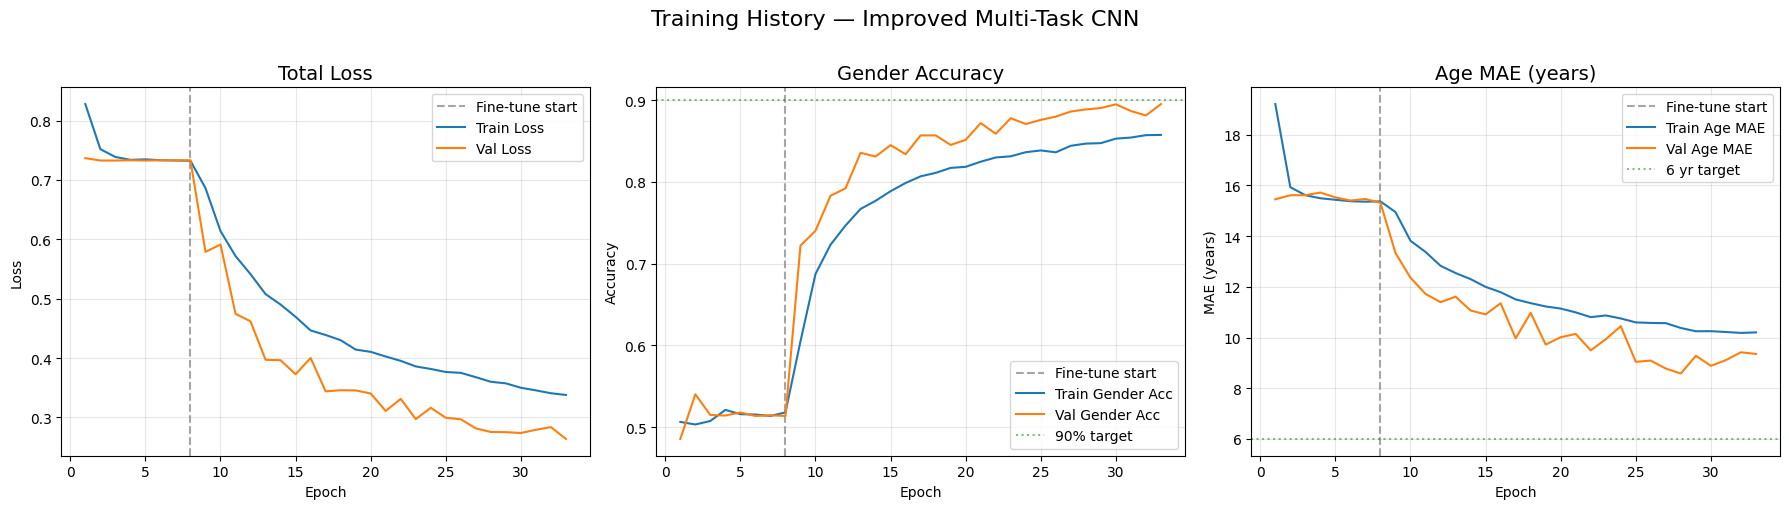

In [17]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
def plot_history(history, stage1_len):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['loss']) + 1)

    for ax in axes:
        ax.axvline(x=stage1_len, color='gray', linestyle='--',
                   alpha=0.7, label='Fine-tune start')

    # ── Total Loss ────────────────────────────────────────────────────────────
    axes[0].plot(epochs, history['loss'],     label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_title('Total Loss', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Gender Accuracy ───────────────────────────────────────────────────────
    axes[1].plot(epochs, history['gender_accuracy'],     label='Train Gender Acc')
    axes[1].plot(epochs, history['val_gender_accuracy'], label='Val Gender Acc')
    axes[1].axhline(y=0.9, color='green', linestyle=':', alpha=0.5, label='90% target')
    axes[1].set_title('Gender Accuracy', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # ── Age MAE (in years) ────────────────────────────────────────────────────
    # Convert normalized MAE back to years
    age_mae_years     = [v * MAX_AGE for v in history['age_mae']]
    val_age_mae_years = [v * MAX_AGE for v in history['val_age_mae']]
    axes[2].plot(epochs, age_mae_years,     label='Train Age MAE')
    axes[2].plot(epochs, val_age_mae_years, label='Val Age MAE')
    axes[2].axhline(y=6, color='green', linestyle=':', alpha=0.5, label='6 yr target')
    axes[2].set_title('Age MAE (years)', fontsize=14)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAE (years)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle('Training History — Improved Multi-Task CNN', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_history(history, stage1_len=len(history1.history['loss']))

In [18]:
# ── Evaluate on Validation Set ────────────────────────────────────────────────
print('Evaluating on validation set...')
results = model.evaluate(val_gen, steps=steps_per_epoch_val, verbose=1)

# Map result values to names
metric_names = model.metrics_names
for name, val in zip(metric_names, results):
    if 'age_mae' in name:
        print(f'{name}: {val * MAX_AGE:.2f} years')
    elif 'accuracy' in name:
        print(f'{name}: {val * 100:.2f}%')
    else:
        print(f'{name}: {val:.4f}')

Evaluating on validation set...
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - age_loss: 0.0153 - age_mae: 0.0909 - gender_accuracy: 0.8987 - gender_loss: 0.2432 - loss: 0.2501
loss: 0.2619
compile_metrics: 0.0160
age_loss: 0.2481
gender_loss: 0.0934


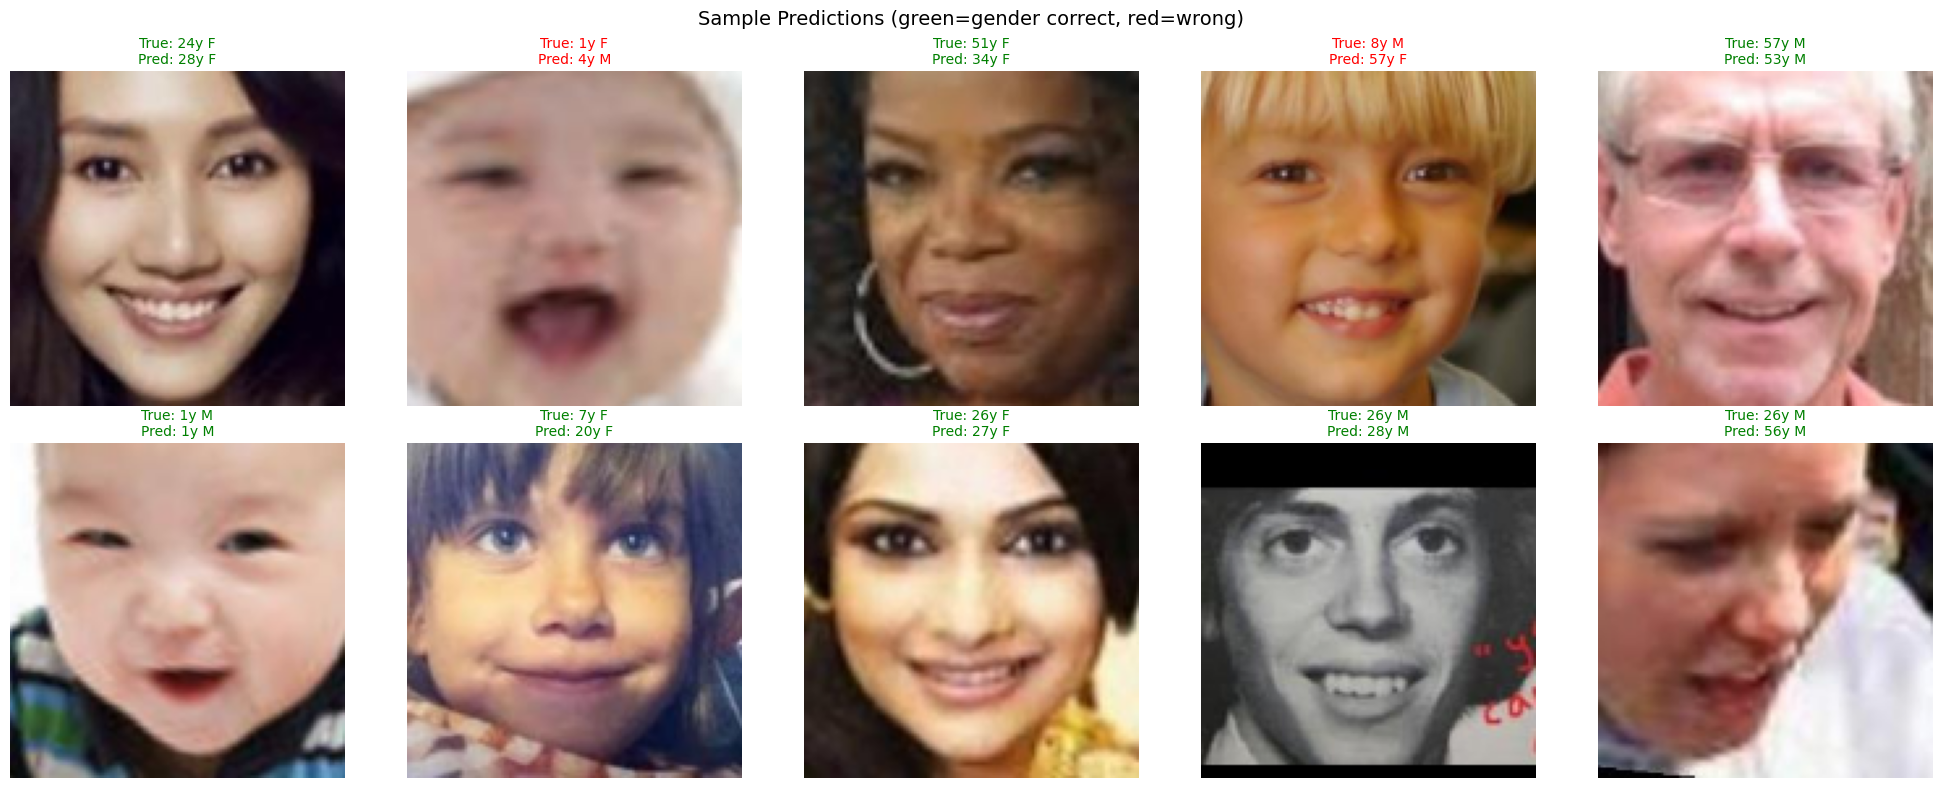

In [19]:
# ── Sample Predictions Visualization ─────────────────────────────────────────
import cv2

def predict_sample(model, val_df, folder_path, n=10):
    """Show a grid of predictions vs ground truth."""
    sample = val_df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n // 2, figsize=(20, 8))
    axes = axes.flatten()

    for i, row in sample.iterrows():
        img = cv2.imread(os.path.join(folder_path, row['img']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        pred = model.predict(np.expand_dims(img_resized, 0), verbose=0)
        pred_age    = int(pred[0][0][0] * MAX_AGE)
        pred_gender = 'F' if pred[1][0][0] > 0.5 else 'M'

        true_age    = row['age']
        true_gender = 'F' if row['gender'] == 1 else 'M'

        gender_correct = pred_gender == true_gender
        color = 'green' if gender_correct else 'red'

        axes[i].imshow(img_resized)
        axes[i].set_title(
            f'True: {true_age}y {true_gender}\nPred: {pred_age}y {pred_gender}',
            color=color, fontsize=10
        )
        axes[i].axis('off')

    plt.suptitle('Sample Predictions (green=gender correct, red=wrong)', fontsize=14)
    plt.tight_layout()
    plt.show()

predict_sample(model, val_df, FOLDER_PATH)

In [20]:
# ── Save Model ────────────────────────────────────────────────────────────────
import joblib

# Use modern Keras format (not legacy .h5)
model.save('age_gender_model_improved.keras')

joblib.dump(IMG_SIZE, 'img_size.pkl')
joblib.dump(MAX_AGE,  'max_age.pkl')
joblib.dump({0: 'Male', 1: 'Female'}, 'gender_classes.pkl')

print('All artifacts saved successfully!')

All artifacts saved successfully!


In [21]:
# ── Download ──────────────────────────────────────────────────────────────────
from google.colab import files
files.download('age_gender_model_improved.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📊 Expected Results After Improvements

| Metric | Original (Broken) | Improved (Expected) |
|--------|------------------|---------------------|
| Gender Accuracy | ~52% (random) | **88–93%** |
| Age MAE | ~15 years | **5–8 years** |
| Training behavior | Flat, no learning | Steady improvement |

## 🔧 Further Improvements (If You Want to Push Further)

1. **Age as Ordinal Classification**: Instead of regression, predict age as one of 8 age groups `[0-12, 13-20, 21-30, ...]`. Often beats pure regression on UTKFace.
2. **Label Smoothing** on gender: Add `label_smoothing=0.1` to `BinaryCrossentropy` to reduce overconfidence.
3. **Test-Time Augmentation (TTA)**: Average predictions over multiple augmented versions of the same image for better accuracy at inference.
4. **Class Weights**: If your gender classes are imbalanced, pass `class_weight` to `model.fit()`.
5. **Larger Backbone**: Try `EfficientNetB4` or `EfficientNetV2S` for better accuracy at the cost of more compute.
6. **Learning Rate Warmup**: Use a cosine decay schedule for more stable fine-tuning.